# Entrega 01 – Análise Descritiva dos Dados

**Análise Inferencial – Projeto Interdisciplinar 4º semestre CCOMP – FECAP / CTI Global**

Professor: Rodinil da Silva Moreira Lisboa

Integrantes: Bruno Nobrega, Kaio Inglez, Mauricio Suster e Yuri Santana

Neste notebook fazemos a análise descritiva dos dados enviados pela CTI: cálculo de média, mediana, moda, variância e desvio padrão, histogramas, boxplots e identificação de valores atípicos (outliers).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Leitura dos dados

O arquivo `Demonstrativo Fecap v3.csv` veio dentro do `DADOS_FECAP.zip`. Ele não tem cabeçalho, usa `;` como separador e vírgula como decimal.

Se estiver rodando no Google Colab, a célula abaixo vai pedir para enviar o arquivo `DADOS_FECAP.zip`.

In [2]:
import os, zipfile

if not os.path.exists('Demonstrativo Fecap v3.csv'):
    from google.colab import files      # só funciona no Colab
    enviados = files.upload()           # enviar o DADOS_FECAP.zip (ou o próprio CSV)
    for nome in enviados:               # funciona mesmo se o arquivo vier como 'DADOS_FECAP (1).zip'
        if nome.lower().endswith('.zip'):
            zipfile.ZipFile(nome).extractall()

dados = pd.read_csv('Demonstrativo Fecap v3.csv', sep=';', encoding='latin1', header=None,
                    names=['ano', 'cenario', 'conta', 'valor'])

# convertendo o valor (formato brasileiro 1.234,56) para número
dados['valor'] = dados['valor'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# deixando ano e cenário como números
dados['ano'] = dados['ano'].str.replace('Ano ', '').astype(int)
dados['cenario'] = dados['cenario'].str.replace('Total Cen_', '').astype(int)

# algumas linhas não têm nome de conta (são linhas de separação/check do arquivo) -> removemos
dados = dados.dropna(subset=['conta'])

print('Total de linhas:', len(dados))
print('Anos:', dados['ano'].min(), 'a', dados['ano'].max())
print('Quantidade de cenários:', dados['cenario'].nunique())
print('Quantidade de contas:', dados['conta'].nunique())
dados.head()

Total de linhas: 958800
Anos: 1 a 12
Quantidade de cenários: 1200
Quantidade de contas: 69


,ano,cenario,conta,valor
1,1,1,BAL - Total do Ativo,1.063113e+10
2,1,1,BAL - Ativo Circulante,1.795721e+09
3,1,1,BAL - Disponível,1.205265e+09
4,1,1,BAL - Contas a Receber - SWAP,9.568042e+07
5,1,1,BAL - Contas a Receber - Partes Relacionadas,5.846615e+05


Cada linha do arquivo é uma conta (por exemplo "DRE - Receita") de um ano e de um cenário. São 12 anos e 1.200 cenários simulados, ou seja, 14.400 demonstrativos.

Para a análise escolhemos 5 variáveis principais:

| Variável | Conta no arquivo |
|---|---|
| Receita | DRE - Receita |
| Custos | DRE - Custos |
| EBITDA | DRE - EBITDA |
| Lucro Líquido | DRE - Resultado Líquido |
| Caixa | BAL - Disponível |

Os valores foram divididos por 1 milhão para ficar em **R\$ milhões**. No arquivo os custos aparecem com sinal negativo, então multiplicamos por -1 para ficarem positivos.

In [3]:
contas = {'DRE - Receita': 'Receita',
          'DRE - Custos': 'Custos',
          'DRE - EBITDA': 'EBITDA',
          'DRE - Resultado Líquido': 'Lucro Líquido',
          'BAL - Disponível': 'Caixa'}

# monta uma tabela com uma linha por cenário/ano e uma coluna por variável
df = dados[dados['conta'].isin(contas.keys())].pivot_table(index=['cenario', 'ano'], columns='conta', values='valor')
df = df.rename(columns=contas)[list(contas.values())] / 1_000_000
df['Custos'] = df['Custos'] * -1
df = df.reset_index()

print('Tamanho da tabela:', df.shape)
df.head()

Tamanho da tabela: (14400, 7)


conta,cenario,ano,Receita,Custos,EBITDA,Lucro Líquido,Caixa
0,1,1,6722.729306,1361.164978,5188.380667,2443.242968,1205.264966
1,1,2,6114.937124,1333.291235,4630.952327,2000.833838,1022.427445
2,1,3,6251.283407,1232.952688,4883.290026,2123.145510,1748.421039
3,1,4,6506.532057,1236.163367,5148.066091,2318.127489,1117.390303
4,1,5,6844.711176,1127.880697,5453.239715,2642.606483,307.386372


## 2. Medidas de posição e de dispersão

Calculamos para cada variável: média, mediana, moda, variância, desvio padrão, mínimo e máximo.

Como os valores são contínuos (quase nunca se repetem), a moda foi calculada como a **classe mais frequente** dividindo os dados em 20 faixas iguais.

In [4]:
variaveis = ['Receita', 'Custos', 'EBITDA', 'Lucro Líquido', 'Caixa']

def moda_classe(coluna):
    faixas = pd.cut(coluna, bins=20)
    faixa = faixas.value_counts().idxmax()
    return f'{faixa.left:,.0f} a {faixa.right:,.0f}'.replace(',', '.')

tabela = pd.DataFrame({
    'Média': df[variaveis].mean(),
    'Mediana': df[variaveis].median(),
    'Moda (classe)': [moda_classe(df[v]) for v in variaveis],
    'Variância': df[variaveis].var(),
    'Desvio padrão': df[variaveis].std(),
    'Mínimo': df[variaveis].min(),
    'Máximo': df[variaveis].max(),
})
tabela.round(2)

,Média,Mediana,Moda (classe),Variância,Desvio padrão,Mínimo,Máximo
conta,,,,,,,
Receita,7913.42,7336.98,6.193 a 6.635,2783659.67,1668.43,5751.58,14589.60
Custos,1205.41,1215.73,1.187 a 1.217,13436.34,115.92,860.76,1454.50
EBITDA,6504.51,5937.50,4.792 a 5.264,3293554.10,1814.82,4320.03,13761.48
Lucro Líquido,3356.65,2978.88,2.312 a 2.641,1776101.37,1332.70,1653.49,8234.44
Caixa,1135.68,1088.18,-21 a 404,725780.62,851.93,-12.60,8329.13


Observações:
- A **média da Receita (R\$ 7.913 mi) é maior que a mediana (R\$ 7.337 mi)**, o que indica assimetria à direita: alguns anos têm receita bem maior que os outros.
- Os **Custos** têm média e mediana parecidas (R\$ 1.205 e R\$ 1.216 mi) e desvio padrão pequeno: variam pouco.
- O **Caixa** é a variável que mais varia em relação à média (desvio de R\$ 852 mi para uma média de R\$ 1.136 mi).

Também calculamos a média por ano, porque os dados crescem com o tempo:

In [5]:
media_ano = df.groupby('ano')[variaveis].mean().round(0)
media_ano

conta,Receita,Custos,EBITDA,Lucro Líquido,Caixa
ano,,,,,
1,6679.0,1356.0,5152.0,2416.0,1118.0
2,6090.0,1323.0,4615.0,1967.0,878.0
3,6255.0,1218.0,4897.0,2113.0,1591.0
4,6514.0,1215.0,5169.0,2302.0,966.0
5,6846.0,1104.0,5473.0,2635.0,257.0
6,7249.0,1111.0,5837.0,2951.0,235.0
7,7674.0,1228.0,6222.0,3142.0,381.0
8,8166.0,1292.0,6651.0,3398.0,1262.0
9,8633.0,1353.0,7062.0,3668.0,1713.0


## 3. Histogramas

Os histogramas mostram como os valores se distribuem.

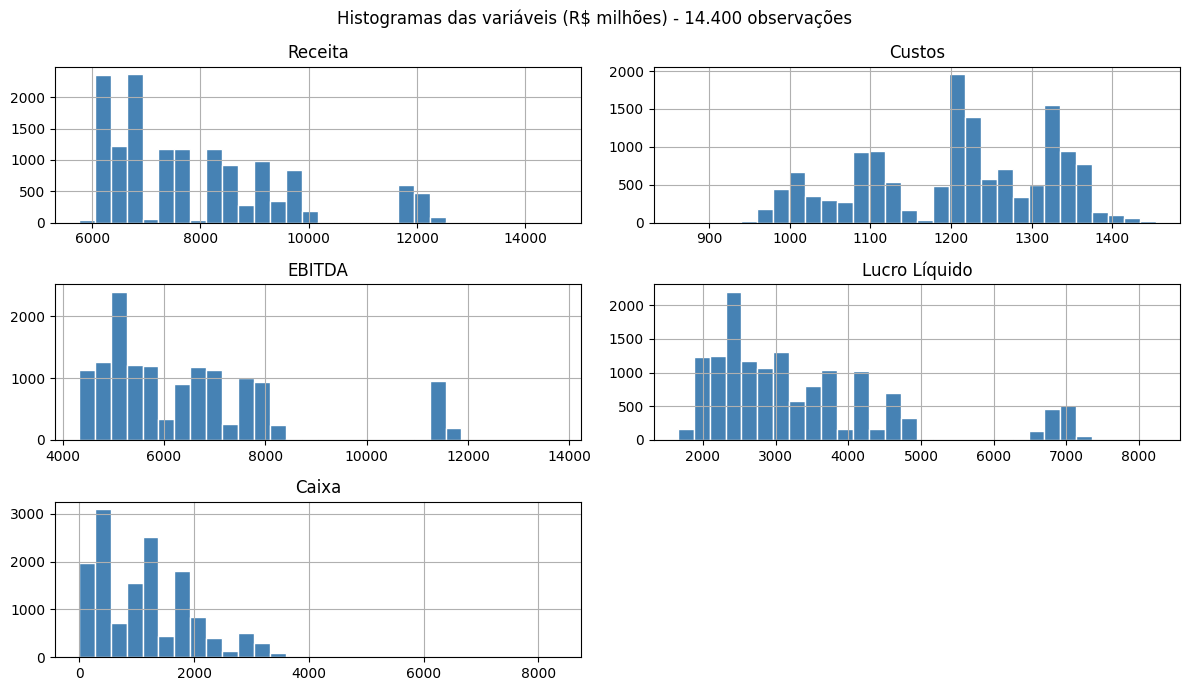

In [6]:
df[variaveis].hist(bins=30, figsize=(12, 7), color='steelblue', edgecolor='white')
plt.suptitle('Histogramas das variáveis (R$ milhões) - 14.400 observações')
plt.tight_layout()
plt.savefig('histogramas.png', dpi=150)
plt.show()

Os histogramas têm vários "picos" porque estamos juntando os 12 anos, e cada ano tem um nível diferente de receita e lucro. O pico isolado à direita na Receita, no EBITDA e no Lucro é o Ano 12 (último ano da concessão), que é bem maior que os outros.

## 4. Boxplots

O boxplot mostra a mediana, os quartis e os pontos atípicos. Primeiro fizemos um boxplot de cada variável e depois por ano, para ver a evolução no tempo.

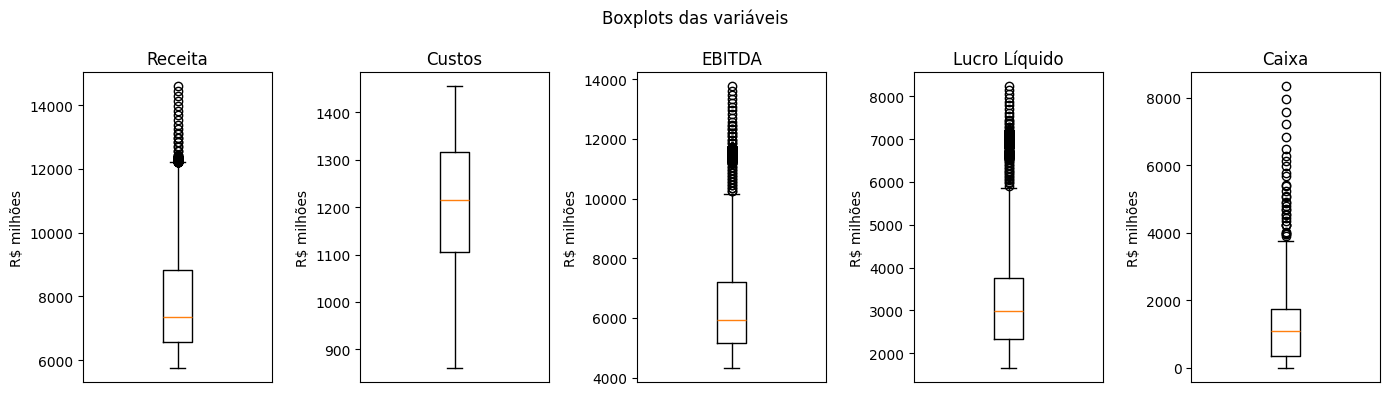

In [7]:
fig, eixos = plt.subplots(1, 5, figsize=(14, 4))
for eixo, v in zip(eixos, variaveis):
    eixo.boxplot(df[v].dropna())
    eixo.set_title(v)
    eixo.set_xticks([])
    eixo.set_ylabel('R$ milhões')
plt.suptitle('Boxplots das variáveis')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150)
plt.show()

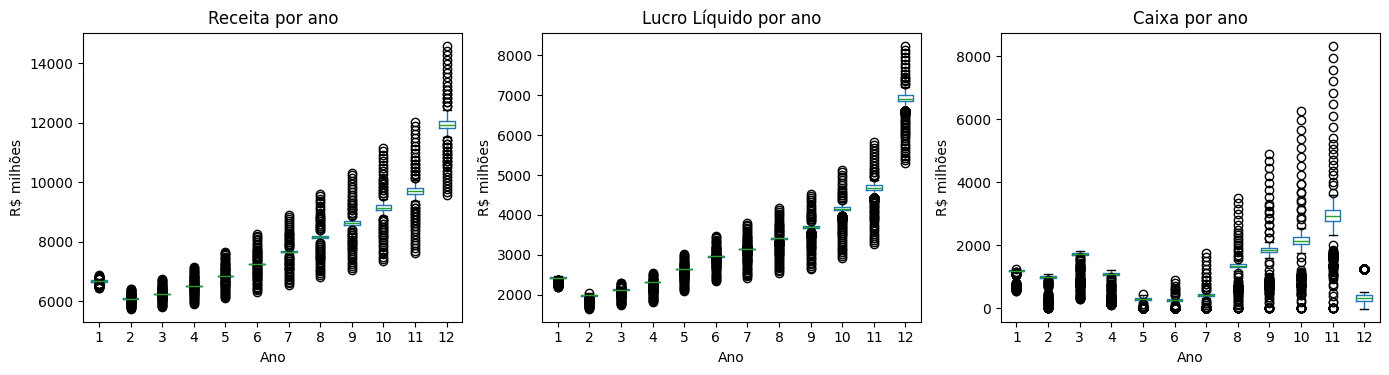

In [8]:
fig, eixos = plt.subplots(1, 3, figsize=(14, 4))
for eixo, v in zip(eixos, ['Receita', 'Lucro Líquido', 'Caixa']):
    df.boxplot(column=v, by='ano', ax=eixo, grid=False)
    eixo.set_title(v + ' por ano')
    eixo.set_xlabel('Ano')
    eixo.set_ylabel('R$ milhões')
plt.suptitle('')
plt.tight_layout()
plt.savefig('boxplots_ano.png', dpi=150)
plt.show()

Nos boxplots por ano dá para ver que:
- A Receita e o Lucro crescem quase todos os anos (só caem no Ano 2) e dão um salto no Ano 12.
- Dentro de um mesmo ano, a Receita e o Lucro variam muito pouco entre os 1.200 cenários (as caixas são bem estreitas).
- O Caixa varia muito mais: cai nos Anos 5, 6 e 7, sobe até o Ano 11 e cai de novo no Ano 12, e tem muitos pontos atípicos.

## 5. Valores atípicos (outliers)

Usamos a regra do boxplot: é atípico o valor abaixo de Q1 − 1,5 × IQR ou acima de Q3 + 1,5 × IQR, sendo IQR = Q3 − Q1.

In [9]:
resultado = []
for v in variaveis:
    q1 = df[v].quantile(0.25)
    q3 = df[v].quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    atipicos = df[(df[v] < limite_inf) | (df[v] > limite_sup)]
    anos = ', '.join(str(a) for a in sorted(atipicos['ano'].unique()))
    resultado.append({'Variável': v, 'Limite inferior': round(limite_inf, 0), 'Limite superior': round(limite_sup, 0),
                      'Qtde de atípicos': len(atipicos), '% do total': round(100 * len(atipicos) / len(df), 2),
                      'Anos em que aparecem': anos})
tabela_outliers = pd.DataFrame(resultado)
tabela_outliers

,Variável,Limite inferior,Limite superior,Qtde de atípicos,% do total,Anos em que aparecem
0,Receita,3181.0,12204.0,140,0.97,12
1,Custos,788.0,1632.0,0,0.00,
2,EBITDA,2119.0,10235.0,1190,8.26,12
3,Lucro Líquido,191.0,5908.0,1190,8.26,12
4,Caixa,-1733.0,3822.0,33,0.23,"9, 10, 11"


Os valores atípicos de Receita, EBITDA e Lucro Líquido são todos do Ano 12, que é o ano de encerramento da concessão (os valores são bem maiores que nos outros anos). Os Custos não têm nenhum valor atípico. No Caixa, os 33 atípicos são cenários que acumularam muito caixa nos Anos 9, 10 e 11.

Como cada ano tem um nível diferente, também verificamos os outliers **dentro de cada ano**, para o Caixa, que foi a variável com mais variação:

In [10]:
atipicos_caixa = []
for ano, grupo in df.groupby('ano'):
    q1 = grupo['Caixa'].quantile(0.25)
    q3 = grupo['Caixa'].quantile(0.75)
    iqr = q3 - q1
    fora = grupo[(grupo['Caixa'] < q1 - 1.5 * iqr) | (grupo['Caixa'] > q3 + 1.5 * iqr)]
    atipicos_caixa.append(fora)
atipicos_caixa = pd.concat(atipicos_caixa)

print('Outliers de Caixa dentro de cada ano:', len(atipicos_caixa), 'de', len(df), 'observações')
print('Quantos deles são de cenários acima de 1000:', (atipicos_caixa['cenario'] > 1000).sum())
print('Cenários diferentes com outlier de caixa:', atipicos_caixa['cenario'].nunique())

Outliers de Caixa dentro de cada ano: 2320 de 14400 observações
Quantos deles são de cenários acima de 1000: 2318
Cenários diferentes com outlier de caixa: 202


Quase todos os outliers de Caixa são dos cenários 1001 a 1200. Olhando esses cenários, vimos que neles a receita varia mais e o caixa muitas vezes chega a zero. Parece ser um grupo de cenários mais "pessimistas" da simulação, e não erro nos dados.

## 6. Conclusões

- A receita da empresa cresce ao longo dos 12 anos (média de R\$ 6,7 bilhões no Ano 1 para R\$ 11,9 bilhões no Ano 12), com queda apenas no Ano 2. Custos ficam praticamente estáveis.
- Dentro de cada ano, receita, EBITDA e lucro variam pouco entre os 1.200 cenários. O caixa é a variável com maior variabilidade.
- A média da receita, do EBITDA e do lucro é maior que a mediana por causa do Ano 12, que é bem maior que os outros anos e concentra os valores atípicos.
- Existe um grupo de cenários (1001 a 1200) com comportamento diferente dos demais, principalmente no caixa. Vamos levar isso em conta na próxima entrega (regressão).